In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd


X_train = pd.read_csv('/content/drive/MyDrive/X_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/X_test.csv')
y_train = pd.read_csv('/content/drive/MyDrive/y_train.csv')
y_test = pd.read_csv('/content/drive/MyDrive/y_test.csv')

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("All loaded!")

X_train: (472432, 233)
X_test:  (118108, 233)
All loaded!


In [5]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("All imports successful!")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports successful!


In [6]:
display(X_train.head())

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,isWeekend,isNightTime,card_combo,P_email_domain_match,P_isGmail,P_isYahoo,card1_transaction_count,card1_avg_amount,amt_vs_card_avg,isMobile
0,1008491,100.00,2,6177,399.0,150.0,0,150.0,1,264.0,...,0,0,10514,1,0,0,16,278.125000,0.358262,0
1,7008212,29.99,4,7900,345.0,150.0,2,224.0,2,143.0,...,0,1,11852,0,1,0,281,97.862463,0.303351,0
2,2071522,107.95,4,11690,111.0,150.0,4,226.0,1,191.0,...,0,1,1471,0,0,0,308,288.750494,0.372562,0
3,13299752,241.95,4,2616,327.0,150.0,1,102.0,1,330.0,...,1,1,7781,0,0,0,4410,270.702556,0.890496,0
4,4412283,117.00,4,13780,298.0,150.0,4,226.0,2,441.0,...,0,1,3273,0,0,0,1008,95.845774,1.208106,0


In [7]:
print("""
Why LSTM beats regular ML for fraud detection:

Regular ML (XGBoost):
- Looks at ONE transaction at a time
- Transaction of $500 looks normal in isolation
- Cannot see the pattern before it

LSTM (Sequential):
- Looks at the LAST N transactions per card
- Sees: $10 → $15 → $12 → $500 (suspicious jump!)
- Learns that sudden changes in behaviour = fraud signal

Real fraud patterns LSTM catches that XGBoost misses:
- Card testing: many small transactions before one large one
- Unusual location jumps between consecutive transactions
- Sudden category changes (groceries → electronics → cash)
- Time compression: 5 transactions in 2 minutes
""")



Why LSTM beats regular ML for fraud detection:

Regular ML (XGBoost):
- Looks at ONE transaction at a time
- Transaction of $500 looks normal in isolation
- Cannot see the pattern before it

LSTM (Sequential):
- Looks at the LAST N transactions per card
- Sees: $10 → $15 → $12 → $500 (suspicious jump!)
- Learns that sudden changes in behaviour = fraud signal

Real fraud patterns LSTM catches that XGBoost misses:
- Card testing: many small transactions before one large one
- Unusual location jumps between consecutive transactions  
- Sudden category changes (groceries → electronics → cash)
- Time compression: 5 transactions in 2 minutes



In [8]:
# These are the most meaningful features for sequential patterns
# We pick time-based, amount-based and card-based features

sequence_features = [
    'TransactionAmt_log',      # how much was spent
    'amt_vs_card_avg',         # how different from card's normal
    'isRoundAmount',           # round amounts are suspicious
    'hour',                    # time of day
    'isNightTime',             # night transaction flag
    'isWeekend',               # weekend flag
    'card1_transaction_count', # how active is this card
    'card1_avg_amount',        # card's normal spend level
    'TransactionAmt_decimal',  # decimal patterns in amounts
    'isMobile',                # device type if available
]

sequence_features = [f for f in sequence_features if f in X_train.columns]

print(f"Using {len(sequence_features)} sequence features:")
for f in sequence_features:
    print(f" - {f}")




Using 10 sequence features:
 - TransactionAmt_log
 - amt_vs_card_avg
 - isRoundAmount
 - hour
 - isNightTime
 - isWeekend
 - card1_transaction_count
 - card1_avg_amount
 - TransactionAmt_decimal
 - isMobile


In [9]:
scalar = StandardScaler()

X_train_seq = X_train[sequence_features].copy()
X_test_seq = X_test[sequence_features].copy()

X_train_seq = X_train_seq.fillna(0)
X_test_seq = X_test_seq.fillna(0)

X_train_scaled = scalar.fit_transform(X_train_seq)
X_test_scaled = scalar.transform(X_test_seq)

print(" Shape" , X_train_scaled.shape)
print("Scaling done")


 Shape (472432, 10)
Scaling done


In [10]:
def create_sequences(X, y, sequence_length = 5):

  """
  Reshape flat transaction rows into sequences.

  Instead of : [tx1], [tx2], [tx3], [tx4], [tx5]  < individual rows
  We create : [[tx1, tx2, tx3, tx4, tx5]]   , one sequence

  Each sequence =  last N transactions seen together
  The label = whether the LAST transaction in the sequence is fraud

  Args :
      X: feature array( rows  = transactions)
      y: fraud labels
      sequence_length : how many transactions per sequence

  Returns:
      X_seq : shape(samples, sequence_length, features)
      y_seq: shape(samples,)

    """

  X_sequences = []
  y_sequences = []

  total = len(X)

  for i in range(sequence_length, total):
    # Grab the last sequence_length transactions

    seq = X[i - sequence_length : i]
    label = y.iloc[i] if hasattr(y, 'iloc') else y[i]

    X_sequences.append(seq)
    y_sequences.append(label)

  return np.array(X_sequences), np.array(y_sequences)

# Use sequence length of 5 (last 5 transactions)
SEQUENCE_LENGTH = 5


print("Creating sequences — this may take a few minutes...")
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train, SEQUENCE_LENGTH
)
X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test, SEQUENCE_LENGTH
)
print(f"\nSequence creation complete!")
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"  → ({X_train_seq.shape[0]} sequences, "
      f"{X_train_seq.shape[1]} timesteps, "
      f"{X_train_seq.shape[2]} features)")
print(f"\nX_test_seq shape:  {X_test_seq.shape}")
print(f"\nFraud rate in sequences: {y_test_seq.mean() * 100:.2f}%")

Creating sequences — this may take a few minutes...

Sequence creation complete!
X_train_seq shape: (472427, 5, 10)
  → (472427 sequences, 5 timesteps, 10 features)

X_test_seq shape:  (118103, 5, 10)

Fraud rate in sequences: 3.50%


Example sequence (label = FRAUD)
Shape: (5, 10) → 5 timesteps × 10 features



,TransactionAmt_log,amt_vs_card_avg,isRoundAmount,hour,isNightTime,isWeekend,card1_transaction_count,card1_avg_amount,TransactionAmt_decimal,isMobile
Timestep,,,,,,,,,,
Transaction t-5,0.112,-0.042,-1.034,0.413,-0.781,-0.636,-0.679,-0.527,1.316,-0.314
Transaction t-4,-0.591,-0.473,-1.034,0.281,-0.781,1.572,-0.376,-0.071,1.408,-0.314
Transaction t-3,-0.326,-0.401,-1.034,1.070,1.280,-0.636,-0.160,-0.067,1.316,-0.314
Transaction t-2,0.677,0.581,0.967,0.676,-0.781,-0.636,-0.681,-0.653,-0.873,-0.314
Transaction t-1,-0.481,-0.205,0.967,-1.690,1.280,-0.636,-0.667,-0.828,-0.873,-0.314


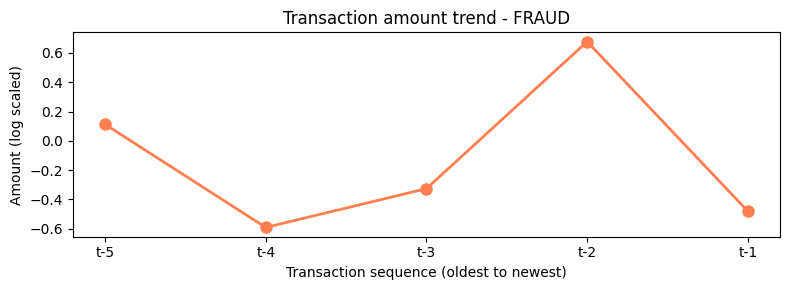

In [11]:
fraud_indices = np.where(y_test_seq ==1 )[0]
example_idx = fraud_indices[0]

example_seq = X_test_seq[example_idx]
example_label = y_test_seq[example_idx]

print(f"Example sequence (label = {'FRAUD' if example_label == 1 else 'LEGITIMATE'})")
print(f"Shape: {example_seq.shape} → 5 timesteps × {len(sequence_features)} features\n")


seq_df = pd.DataFrame(example_seq, columns=sequence_features)
seq_df.index = [f'Transaction t-{SEQUENCE_LENGTH -i}' for i in range(SEQUENCE_LENGTH)]

seq_df.index.name = 'Timestep'
display(seq_df.round(3))

plt.figure(figsize=(8,3))
plt.plot(range(SEQUENCE_LENGTH),
         example_seq[:,0],
         marker='o' , color='coral', linewidth=2, markersize=8)

plt.title(f'Transaction amount trend - {"FRAUD" if example_label else "LEGITIMATE"}')
plt.xlabel('Transaction sequence (oldest to newest)')
plt.ylabel('Amount (log scaled)')
plt.xticks(range(SEQUENCE_LENGTH),
           [f't-{SEQUENCE_LENGTH-i}' for i in range(SEQUENCE_LENGTH)])
plt.tight_layout()
plt.show()

In [12]:

# Calculate class weight to handle fraud imbalance

fraud_count =  int(y_train_seq.sum())
legit_count = int(len(y_train_seq) - fraud_count)
total = len(y_train_seq)

#Weight inversely proportional to class frequency

weight_for_0 = (1 / legit_count) * (total / 2.0)
weight_for_1 = (1 / fraud_count) * (total / 2.0)

class_weights = {0: weight_for_0, 1: weight_for_1}

print(" Class weights :")
print(f" Legitimate (0) : {weight_for_0:.4f}")
print(f"Fraud (1) : {weight_for_1:.4f}")
print(f"\nFraud weight is {weight_for_1 / weight_for_0:.1f}x higher than legitimate")
print("This tells the LSTM to penalise missed fraud much more heavily")

 Class weights :
 Legitimate (0) : 0.5181
Fraud (1) : 14.2900

Fraud weight is 27.6x higher than legitimate
This tells the LSTM to penalise missed fraud much more heavily


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam

SEQUENCE_LENGTH = 5

n_features = X_train_seq.shape[2]

model = Sequential([
    # First  LSTM layer short term transactions
    LSTM(
        units=64,
        input_shape=(SEQUENCE_LENGTH, n_features),
        return_sequences=True
    ),
    BatchNormalization(),
    Dropout(0.3),        # prevents overfitting

    #Second Layer long term transaction
    LSTM(
        units =32,
        return_sequences=False  # to return final output
    ),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')

])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,545 (127.13 KB)

 Trainable params: 32,353 (126.38 KB)

 Non-trainable params: 192 (768.00 B)

In [14]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True, verbose=1),

    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max',verbose=1)
    ]


print("Callbacks ready!")
print("- EarlyStopping: stops if val_auc doesn't improve for 5 epochs")
print("- ReduceLROnPlateau: halves learning rate if stuck for 3 epochs")

Callbacks ready!
- EarlyStopping: stops if val_auc doesn't improve for 5 epochs
- ReduceLROnPlateau: halves learning rate if stuck for 3 epochs


In [15]:
print("Training LSTM — this will take 10-20 minutes...")
print("Watch the val_auc metric — that's what matters most\n")


history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    class_weight= class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete !")

Training LSTM — this will take 10-20 minutes...
Watch the val_auc metric — that's what matters most

Epoch 1/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.5128 - auc: 0.5010 - loss: 0.7150 - precision: 0.0353 - recall: 0.4901 - val_accuracy: 0.5705 - val_auc: 0.4840 - val_loss: 0.6887 - val_precision: 0.0332 - val_recall: 0.4070 - learning_rate: 0.0010
Epoch 2/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5342 - auc: 0.5021 - loss: 0.6961 - precision: 0.0354 - recall: 0.4678 - val_accuracy: 0.3425 - val_auc: 0.4833 - val_loss: 0.7019 - val_precision: 0.0331 - val_recall: 0.6409 - learning_rate: 0.0010
Epoch 3/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4880 - auc: 0.5044 - loss: 0.6943 - precision: 0.0356 - recall: 0.5209 - val_accuracy: 0.6694 - val_auc: 0.4842 - val_loss: 0.6883 - val_precision: 0.0326 - val_recall: 0.2996 - learning_rate: 0.0010
Epoch 4/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4752 - auc: 0.5077 - loss: 0.

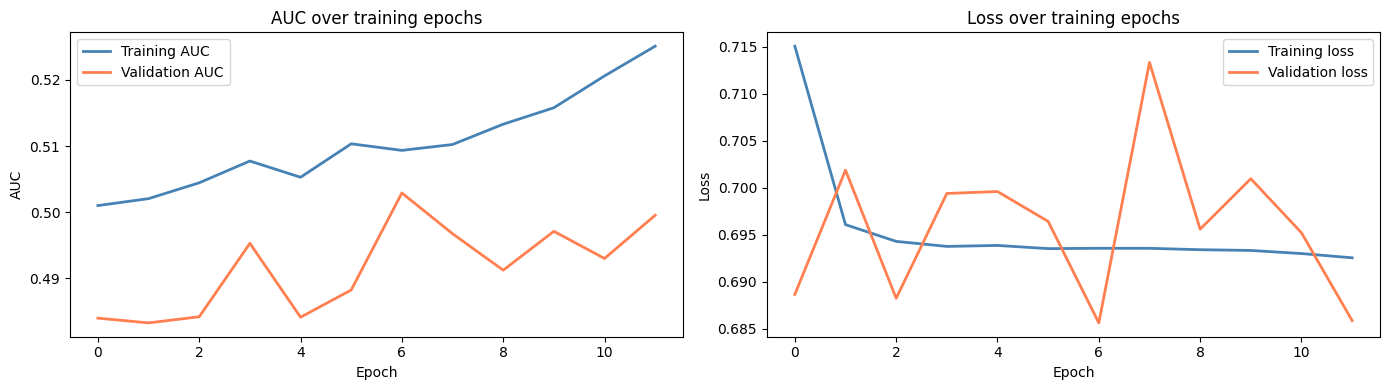

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# AUC over epochs
axes[0].plot(history.history['auc'],
             label='Training AUC', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_auc'],
             label='Validation AUC', color='coral', linewidth=2)
axes[0].set_title('AUC over training epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# Loss over epochs
axes[1].plot(history.history['loss'],
             label='Training loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation loss', color='coral', linewidth=2)
axes[1].set_title('Loss over training epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


=== LSTM Results ===

              precision    recall  f1-score   support

  Legitimate       0.96      0.65      0.78    113970
       Fraud       0.03      0.34      0.06      4133

    accuracy                           0.64    118103
   macro avg       0.50      0.50      0.42    118103
weighted avg       0.93      0.64      0.75    118103

AUC Score:         0.493
Average Precision: 0.034


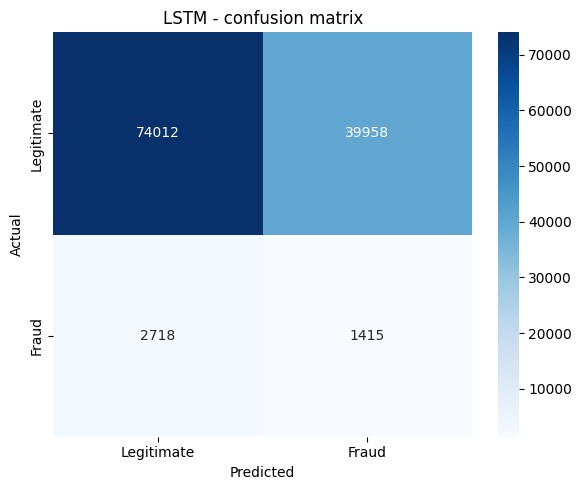

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob = model.predict(X_test_seq, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test_seq, y_prob)
ap = average_precision_score(y_test_seq, y_prob)

print("=== LSTM Results ===\n")
print(classification_report(y_test_seq, y_pred, target_names=['Legitimate' , 'Fraud']))


print(f"AUC Score:         {auc:.3f}")
print(f"Average Precision: {ap:.3f}")

cm = confusion_matrix(y_test_seq, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM - confusion matrix')
plt.tight_layout()
plt.show()



In [20]:
# Run this in Colab to save your model
model.save('lstm_fraud_model.keras')

lstm_results = pd.DataFrame({
    'lstm_probability': y_prob,
    'lstm_predicted':   y_pred,
    'actual_fraud':     y_test_seq.flatten()

})

lstm_results.to_csv('lstm_scores.csv', index = False)
print(f"Saved {len(lstm_results):,} predictions")
print("\nPhase 3 - LSTM complete!")

Saved 118,103 predictions

Phase 3 - LSTM complete!
